In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [42]:
# Load data
df = pd.read_csv('full_image_data_feb_25.csv', low_memory=False)
books = pd.read_csv('full_book_data_feb_25.csv', low_memory=False)

df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

In [43]:
# Filter for motions of the sun CKs, then merge visual tags
target_cks = [
    'CK_Inequality of Natural Days',
    'CK_Circles of Natural Days',
    'CK_Sun Orbit',
    'CK_Movement of the Sun'
]

images_with_target = df[df['cks'].isin(target_cks)]['images'].unique()
filtered_df = df[df['images'].isin(images_with_target)].copy()

visual_tags = pd.read_excel('/Users/nogashlomi/projects/Image_data/visual_tags/VT_3.3.xlsx')
visual_df = pd.merge(filtered_df, visual_tags, on='cluster_name')

# Keep only rows with target CKs and prepare columns
base_df = visual_df[visual_df['cks'].isin(target_cks)].copy()
base_df['year'] = pd.to_numeric(base_df['year'], errors='coerce')
base_df['custom_identifier_str'] = base_df['custom_identifier'].astype(str)
base_df = base_df.dropna(subset=['year', 'place', 'custom_identifier']).sort_values('year')

print(f'Total rows: {len(base_df)}')
print(f'Unique images: {base_df["images"].nunique()}')
print(f'Unique books: {base_df["book"].nunique()}')

Total rows: 1216
Unique images: 1208
Unique books: 274


## Color = Yes

In [44]:
# Filter: sun motion CKs AND color = yes
color_df = base_df[base_df['color'] == 'yes'].copy()

print(f'Rows (color=yes): {len(color_df)}')
print(f'Unique images: {color_df["images"].nunique()}')
print(f'Unique books: {color_df["book"].nunique()}')

Rows (color=yes): 499
Unique images: 494
Unique books: 232


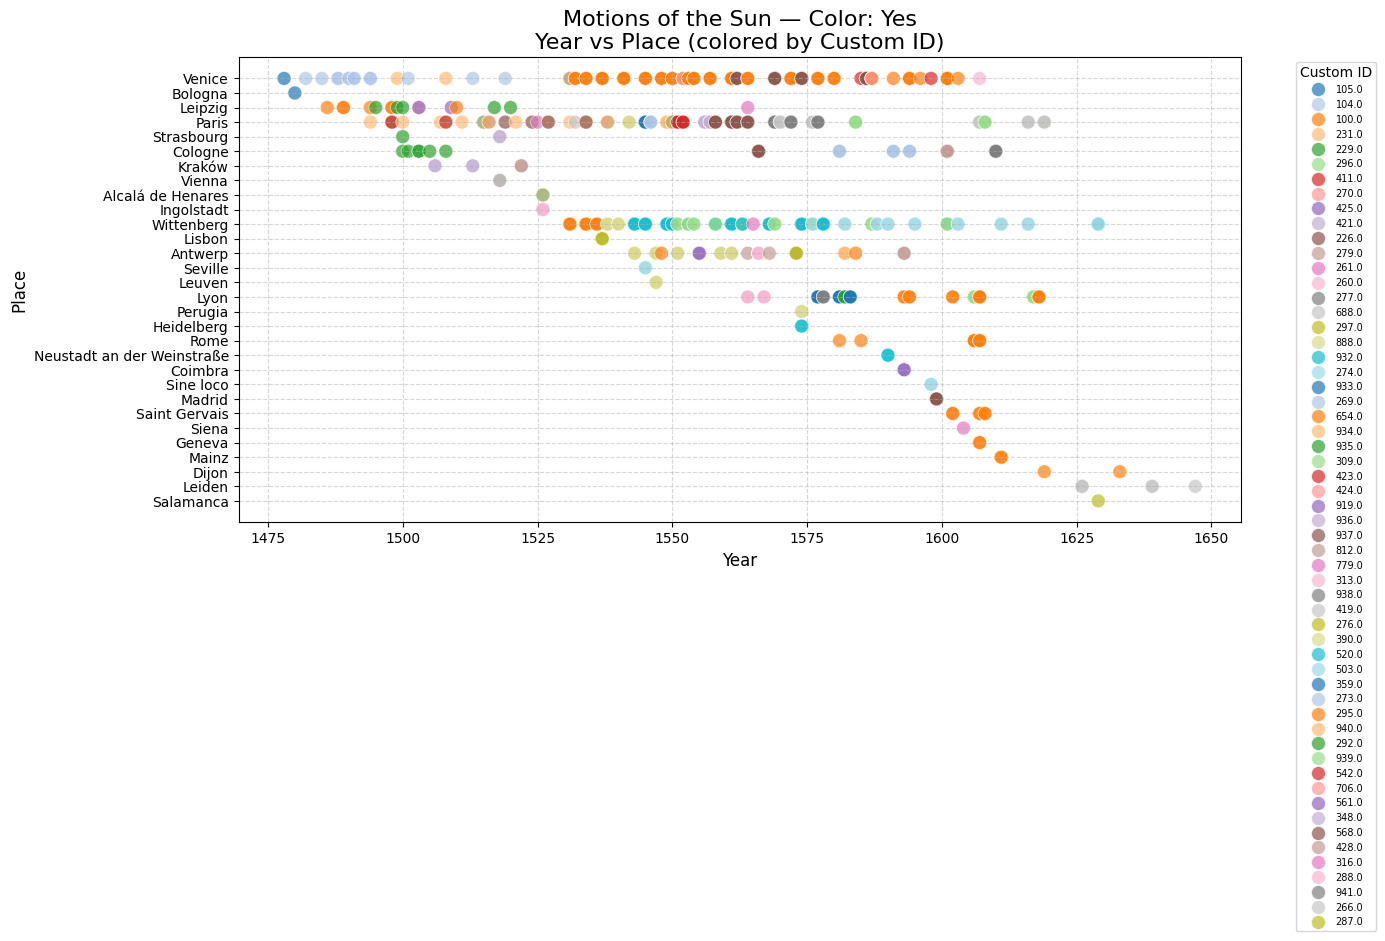

In [45]:
# Static scatter: color=yes — x=year, y=place, hue=custom_id
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=color_df,
    x='year',
    y='place',
    hue='custom_identifier_str',
    palette='tab20',
    s=100,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Motions of the Sun — Color: Yes\nYear vs Place (colored by Custom ID)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Place', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Custom ID', fontsize=7)
plt.tight_layout()
plt.savefig('sun_motion_color_yes_scatter.png', dpi=300)
plt.show()

In [46]:
# Interactive scatter: color=yes
fig = px.scatter(
    color_df,
    x='year',
    y='place',
    color='custom_identifier_str',
    hover_data=['cks', 'part_or_adaption_label', 'book', 'custom_identifier_str'],
    title='Motions of the Sun — Color: Yes (Interactive)',
    labels={'year': 'Year', 'place': 'Place', 'custom_identifier_str': 'Custom ID'}
)
fig.update_layout(height=700)
fig.show()

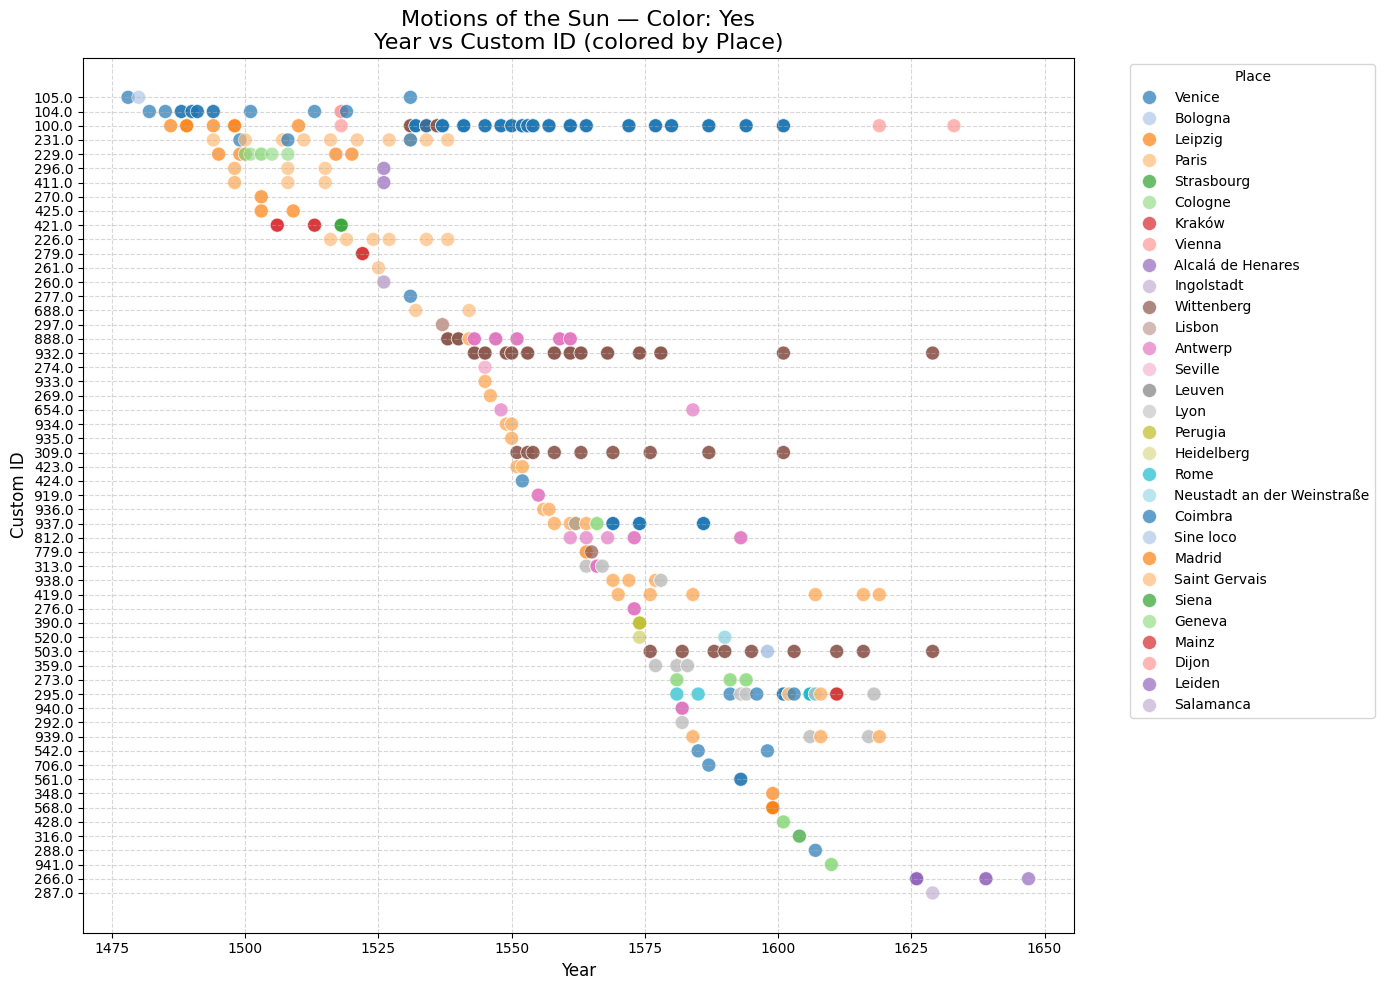

In [47]:
# Static scatter: color=yes — x=year, y=custom_id, hue=place
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=color_df,
    x='year',
    y='custom_identifier_str',
    hue='place',
    palette='tab20',
    s=100,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Motions of the Sun — Color: Yes\nYear vs Custom ID (colored by Place)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Custom ID', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Place')
plt.tight_layout()
plt.savefig('sun_motion_color_yes_by_custom_id.png', dpi=300)
plt.show()

In [48]:
# Interactive scatter: color=yes — y=custom_id, color=place
fig = px.scatter(
    color_df,
    x='year',
    y='custom_identifier_str',
    color='place',
    hover_data=['cks', 'part_or_adaption_label', 'book', 'custom_identifier_str'],
    title='Motions of the Sun — Color: Yes — Year vs Custom ID (Interactive)',
    labels={'year': 'Year', 'custom_identifier_str': 'Custom ID', 'place': 'Place'}
)
fig.update_layout(height=800)
fig.show()

## Multiple Subjects Sun and Moon = Yes

In [49]:
# Filter: sun motion CKs AND multiple subjects sun and moon = yes
multi_df = base_df[base_df['multiple subjects sun and moon'] == 'yes'].copy()

print(f'Rows (multiple subjects=yes): {len(multi_df)}')
print(f'Unique images: {multi_df["images"].nunique()}')
print(f'Unique books: {multi_df["book"].nunique()}')

Rows (multiple subjects=yes): 76
Unique images: 76
Unique books: 56


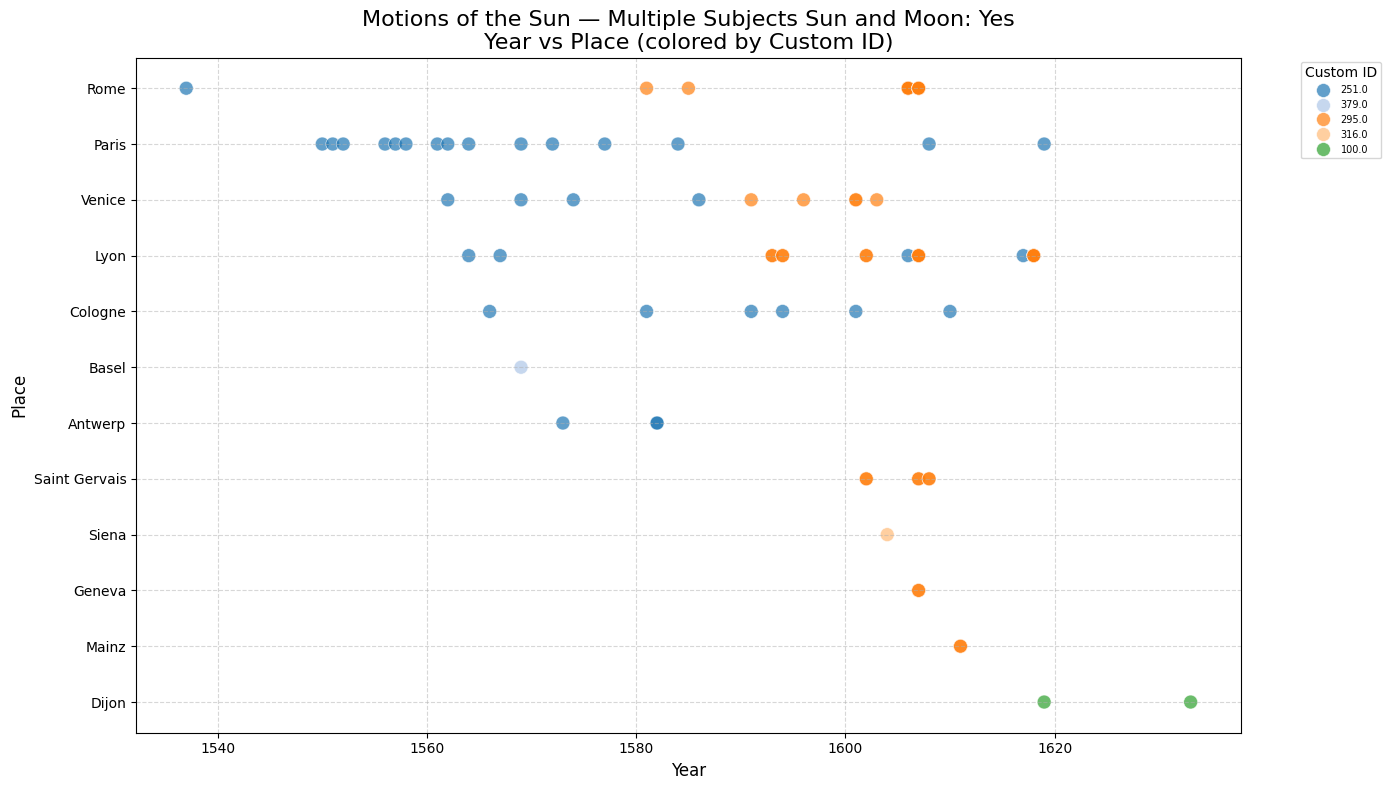

In [50]:
# Static scatter: multiple subjects=yes — x=year, y=place, hue=custom_id
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=multi_df,
    x='year',
    y='place',
    hue='custom_identifier_str',
    palette='tab20',
    s=100,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Motions of the Sun — Multiple Subjects Sun and Moon: Yes\nYear vs Place (colored by Custom ID)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Place', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Custom ID', fontsize=7)
plt.tight_layout()
plt.savefig('sun_motion_multiple_subjects_yes_scatter.png', dpi=300)
plt.show()

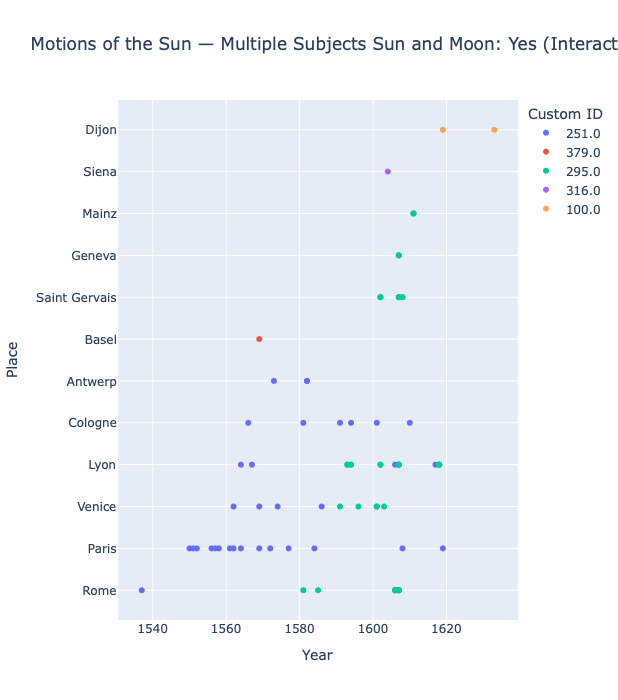

In [51]:
# Interactive scatter: multiple subjects=yes
fig = px.scatter(
    multi_df,
    x='year',
    y='place',
    color='custom_identifier_str',
    hover_data=['cks', 'part_or_adaption_label', 'book', 'custom_identifier_str'],
    title='Motions of the Sun — Multiple Subjects Sun and Moon: Yes (Interactive)',
    labels={'year': 'Year', 'place': 'Place', 'custom_identifier_str': 'Custom ID'}
)
fig.update_layout(height=700)
fig.show()

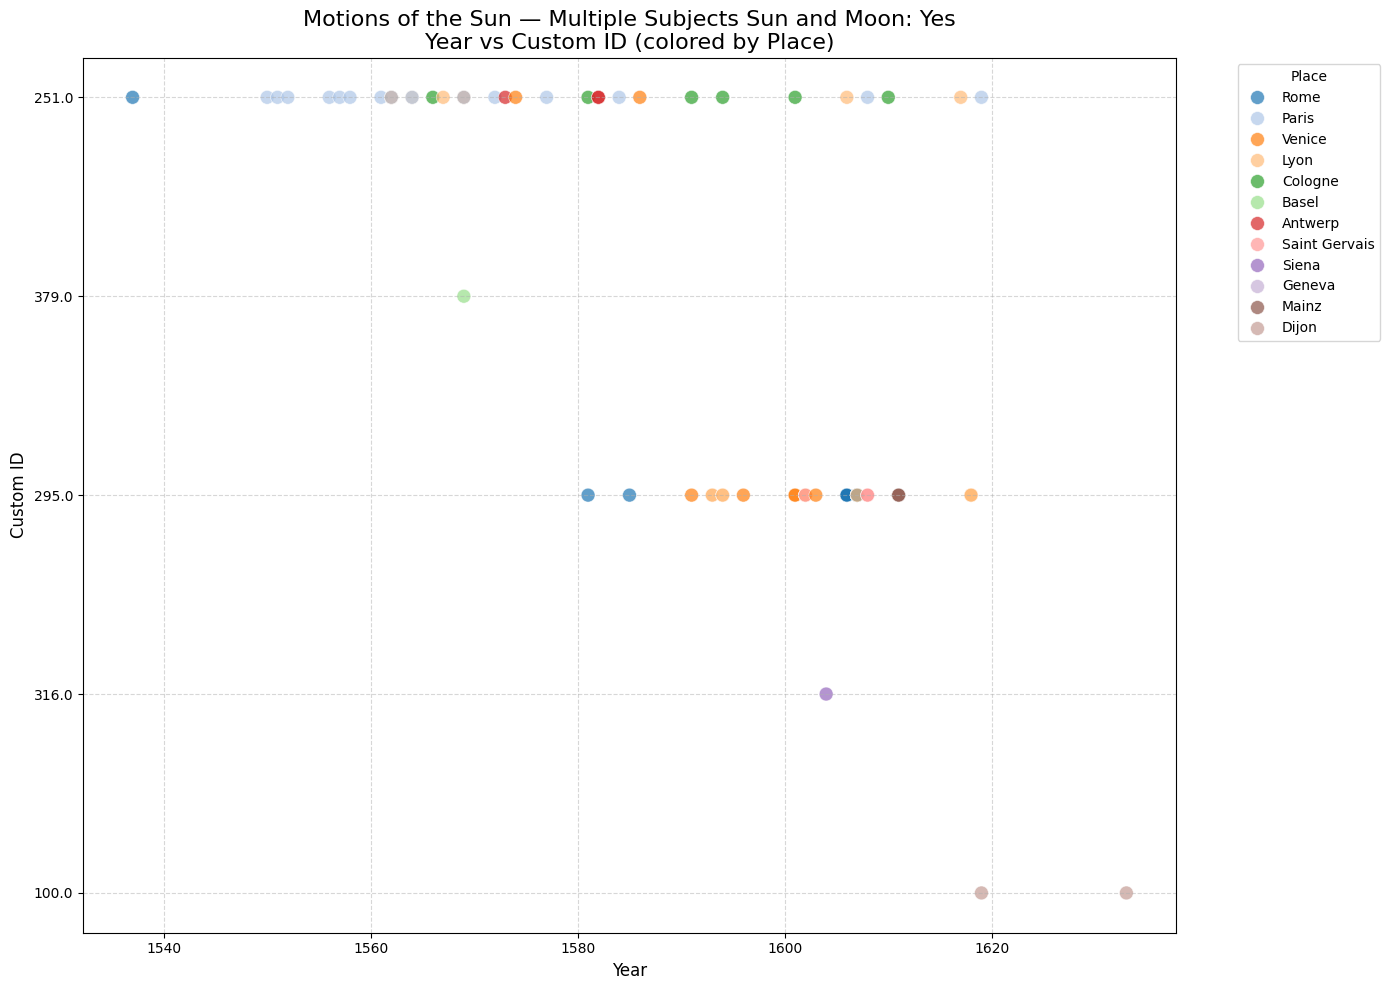

In [52]:
# Static scatter: multiple subjects=yes — x=year, y=custom_id, hue=place
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=multi_df,
    x='year',
    y='custom_identifier_str',
    hue='place',
    palette='tab20',
    s=100,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Motions of the Sun — Multiple Subjects Sun and Moon: Yes\nYear vs Custom ID (colored by Place)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Custom ID', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Place')
plt.tight_layout()
plt.savefig('sun_motion_multiple_subjects_yes_by_custom_id.png', dpi=300)
plt.show()

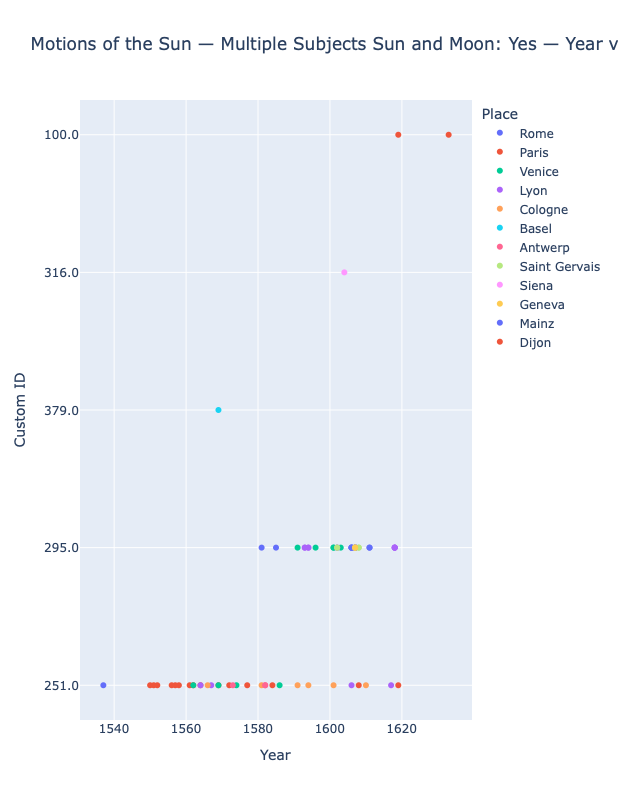

In [53]:
# Interactive scatter: multiple subjects=yes — y=custom_id, color=place
fig = px.scatter(
    multi_df,
    x='year',
    y='custom_identifier_str',
    color='place',
    hover_data=['cks', 'part_or_adaption_label', 'book', 'custom_identifier_str'],
    title='Motions of the Sun — Multiple Subjects Sun and Moon: Yes — Year vs Custom ID (Interactive)',
    labels={'year': 'Year', 'custom_identifier_str': 'Custom ID', 'place': 'Place'}
)
fig.update_layout(height=800)
fig.show()

## CK_Stationary and Retrograde Motion

In [54]:
# Filter: CK_Stationary and Retrograde Motion
retro_df = df[df['cks'] == 'CK_Stationary and Retrograde Motion'].copy()
retro_df['year'] = pd.to_numeric(retro_df['year'], errors='coerce')
retro_df['custom_identifier_str'] = retro_df['custom_identifier'].astype(str)
retro_df = retro_df.dropna(subset=['year', 'place', 'custom_identifier']).sort_values('year')

print(f'Rows: {len(retro_df)}')
print(f'Unique images: {retro_df["images"].nunique()}')
print(f'Unique books: {retro_df["book"].nunique()}')

Rows: 132
Unique images: 131
Unique books: 44


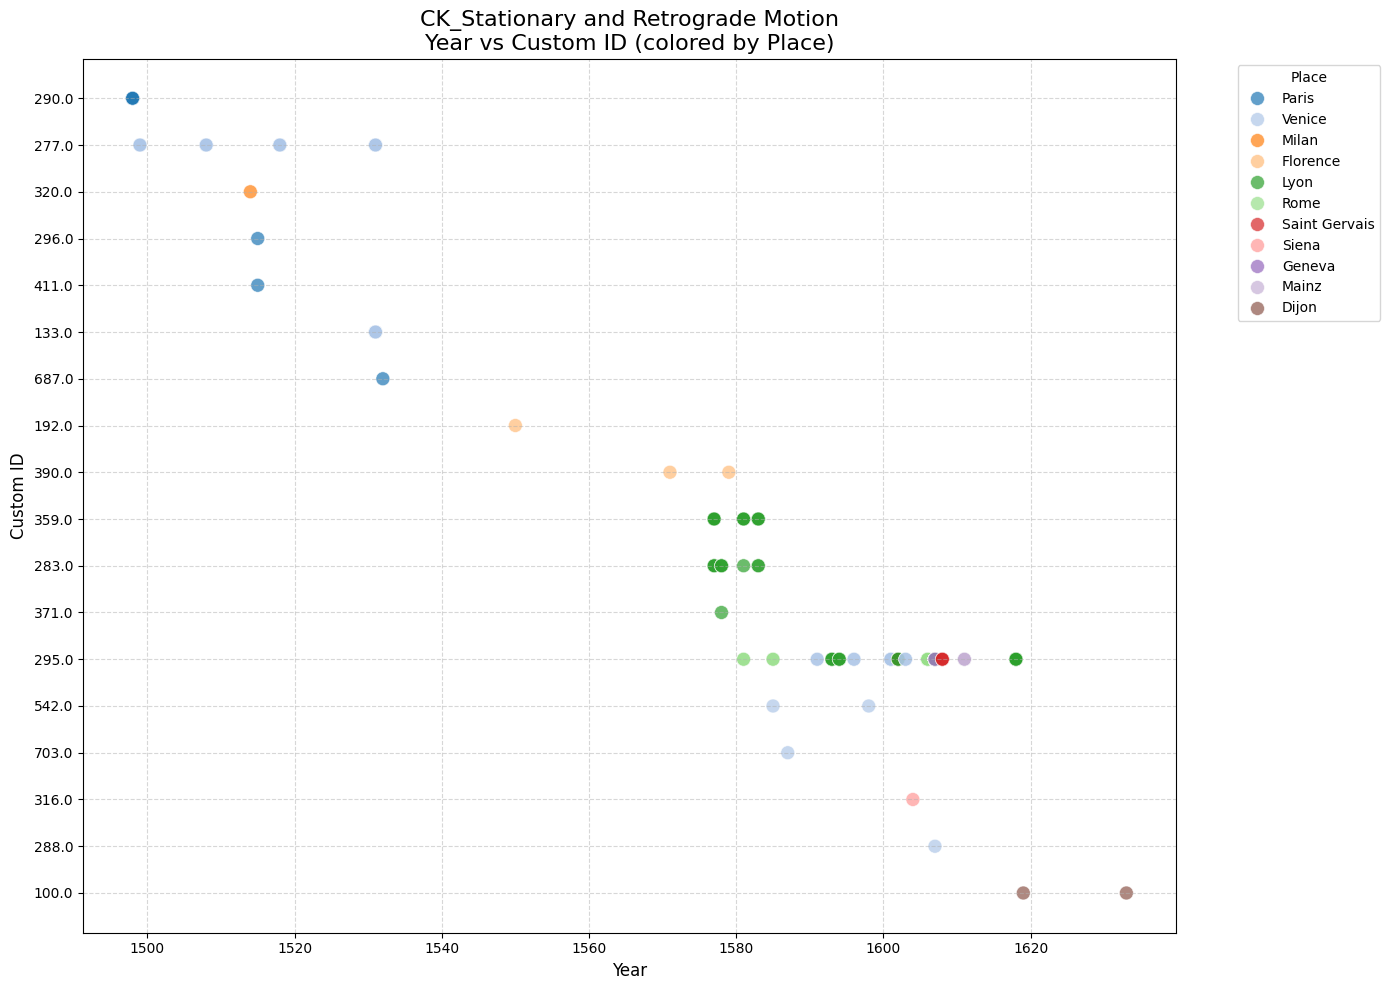

In [55]:
# Static scatter: CK_Stationary and Retrograde Motion — x=year, y=custom_id, hue=place
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=retro_df,
    x='year',
    y='custom_identifier_str',
    hue='place',
    palette='tab20',
    s=100,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

plt.title('CK_Stationary and Retrograde Motion\nYear vs Custom ID (colored by Place)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Custom ID', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Place')
plt.tight_layout()
plt.savefig('sun_motion_stationary_retrograde_by_custom_id.png', dpi=300)
plt.show()

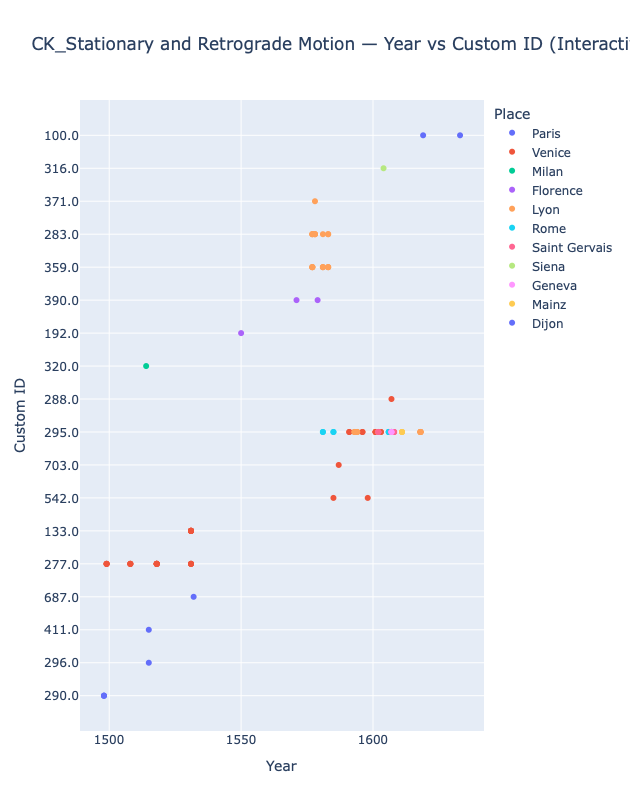

In [56]:
# Interactive scatter: CK_Stationary and Retrograde Motion
fig = px.scatter(
    retro_df,
    x='year',
    y='custom_identifier_str',
    color='place',
    hover_data=['part_or_adaption_label', 'book', 'custom_identifier_str'],
    title='CK_Stationary and Retrograde Motion — Year vs Custom ID (Interactive)',
    labels={'year': 'Year', 'custom_identifier_str': 'Custom ID', 'place': 'Place'}
)
fig.update_layout(height=800)
fig.show()